In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import AFT_tools as AFT

plt.style.use('../libs/my_style.mplstyle')

path='/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002'

green = zarr.open_array(os.path.join(path, "MTs.zarr"), read_only=True)
red =  zarr.open_array(os.path.join(path, "MTs_red.zarr"), read_only=True)

In [ ]:
# AFT parameters
window_size_um = 10 # MTs length = 10um
frame = 100

scale = 0.11  # um/pixel

#### required parameters ####
window_size = int(window_size_um/scale)
overlap = 0.8
neighborhood_radius = 1

d = 30

In [ ]:
x, y, u, v, im_theta, im_eccentricity = AFT.image_local_order(green[:,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,
                                                             plot_overlay=False, plot_angles=False, plot_eccentricity=False,
                                                             save_figures=False)

"\nx_red, y_red, u_red, v_red, im_theta_red, im_eccentricity_red = AFT.image_local_order(red[:,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,\n                                                             plot_overlay=False, plot_angles=False, plot_eccentricity=False,\n                                                             save_figures=False)\n                                                             "

Calculating Polar Order...


100%|██████████| 1001/1001 [08:04<00:00,  2.07it/s]


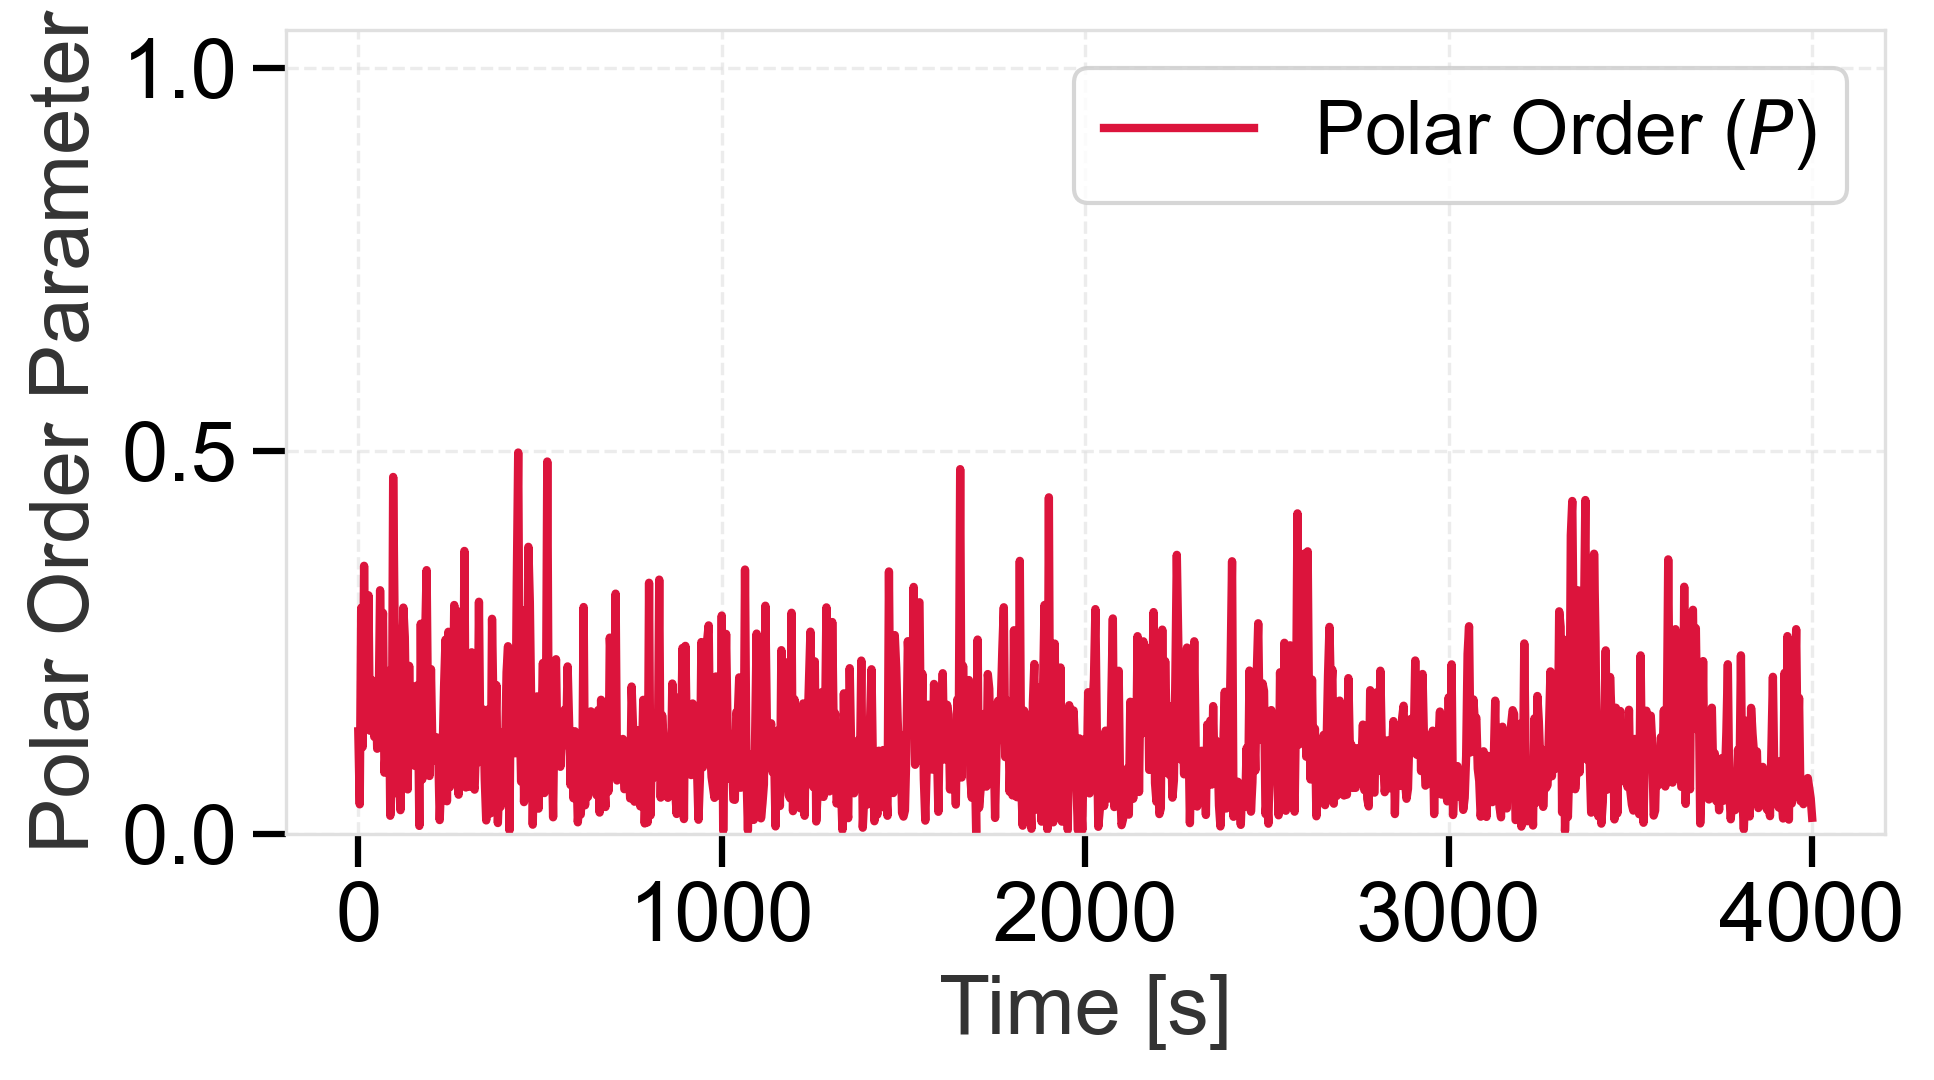

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tqdm import tqdm

# --- 1. 定数とデータの準備 ---
# AFT.image_local_order の戻り値を theta_stack, ecc_stack とします
# theta_stack の形状は (frames, rows, cols) にリシェイプされている前提です

num_frames = green.shape[0]
polar_order_list = []
interval = 4  # 時間間隔(秒)などはご自身の実験系に合わせてください

print("Calculating Polar Order...")

for f in tqdm(range(1, num_frames)):
    # a. フレームの取得とオプティカルフロー計算
    prev_frame = green[f-1, :, :].astype(np.uint8)
    curr_frame = green[f, :, :].astype(np.uint8)
    flow = cv2.calcOpticalFlowFarneback(prev_frame, curr_frame, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    
    # b. 現在のフレームの角度マップと離心率マップを取得
    curr_theta = im_theta[f]  # shape: (rows, cols)
    
    u_polar = []
    v_polar = []
    
    # 窓（グリッド）ごとにループ
    rows, cols = curr_theta.shape
    for r in range(rows):
        for c in range(cols):
            theta = curr_theta[r, c]
            
            # c. im_theta から単位ベクトルを生成
            # AFTの結果は -pi/2 ~ pi/2 なので、そのまま cos, sin を計算
            ui = np.cos(theta)
            vi = np.sin(theta)
            
            # d. 窓の中心に対応するオプティカルフローを取得
            # 注: AFTのグリッド座標 (x[c], y[r]) を使用する必要があります
            target_x, target_y = int(x[c]), int(y[r])
            move_x = flow[target_y, target_x, 0]
            move_y = flow[target_y, target_x, 1]
            
            # e. 内積による極性判定
            # 単位ベクトルと移動方向が逆（90度より大きい開き）なら反転
            if (ui * move_x + vi * move_y) < 0:
                u_polar.append(-ui)
                v_polar.append(-vi)
            else:
                u_polar.append(ui)
                v_polar.append(vi)
    
    # f. ポーラー度の計算
    # 1. リストをNumPy配列に変換
    u_array = np.array(u_polar)
    v_array = np.array(v_polar)

    # 2. 有効なデータ点が存在するかチェック
    # np.nanmean はすべてが NaN だと警告を出すため、有効なデータが1つ以上あるか確認します
    if np.any(~np.isnan(u_array)):
        # NaNを無視して平均ベクトルを算出
        mean_u = np.nanmean(u_array)
        mean_v = np.nanmean(v_array)
        
        # ポーラー度 P = sqrt( <cosθ>^2 + <sinθ>^2 )
        p_val = np.sqrt(mean_u**2 + mean_v**2)
        polar_order_list.append(p_val)
    else:
        # そのフレームに有効な微小管が一つもない場合
        polar_order_list.append(np.nan)

# --- 2. グラフ化 ---
time_axis = np.arange(len(polar_order_list)) * interval

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(time_axis, polar_order_list, color='crimson', lw=2, label='Polar Order ($P$)')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Polar Order Parameter')
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show()

In [59]:
polar_array = np.array(polar_order_list)
zarr_polar = zarr.open(os.path.join(path, "polar_AFT.zarr"), mode = 'w', shape = polar_array.shape, dtype = polar_array.dtype)
zarr_polar[:] = polar_array

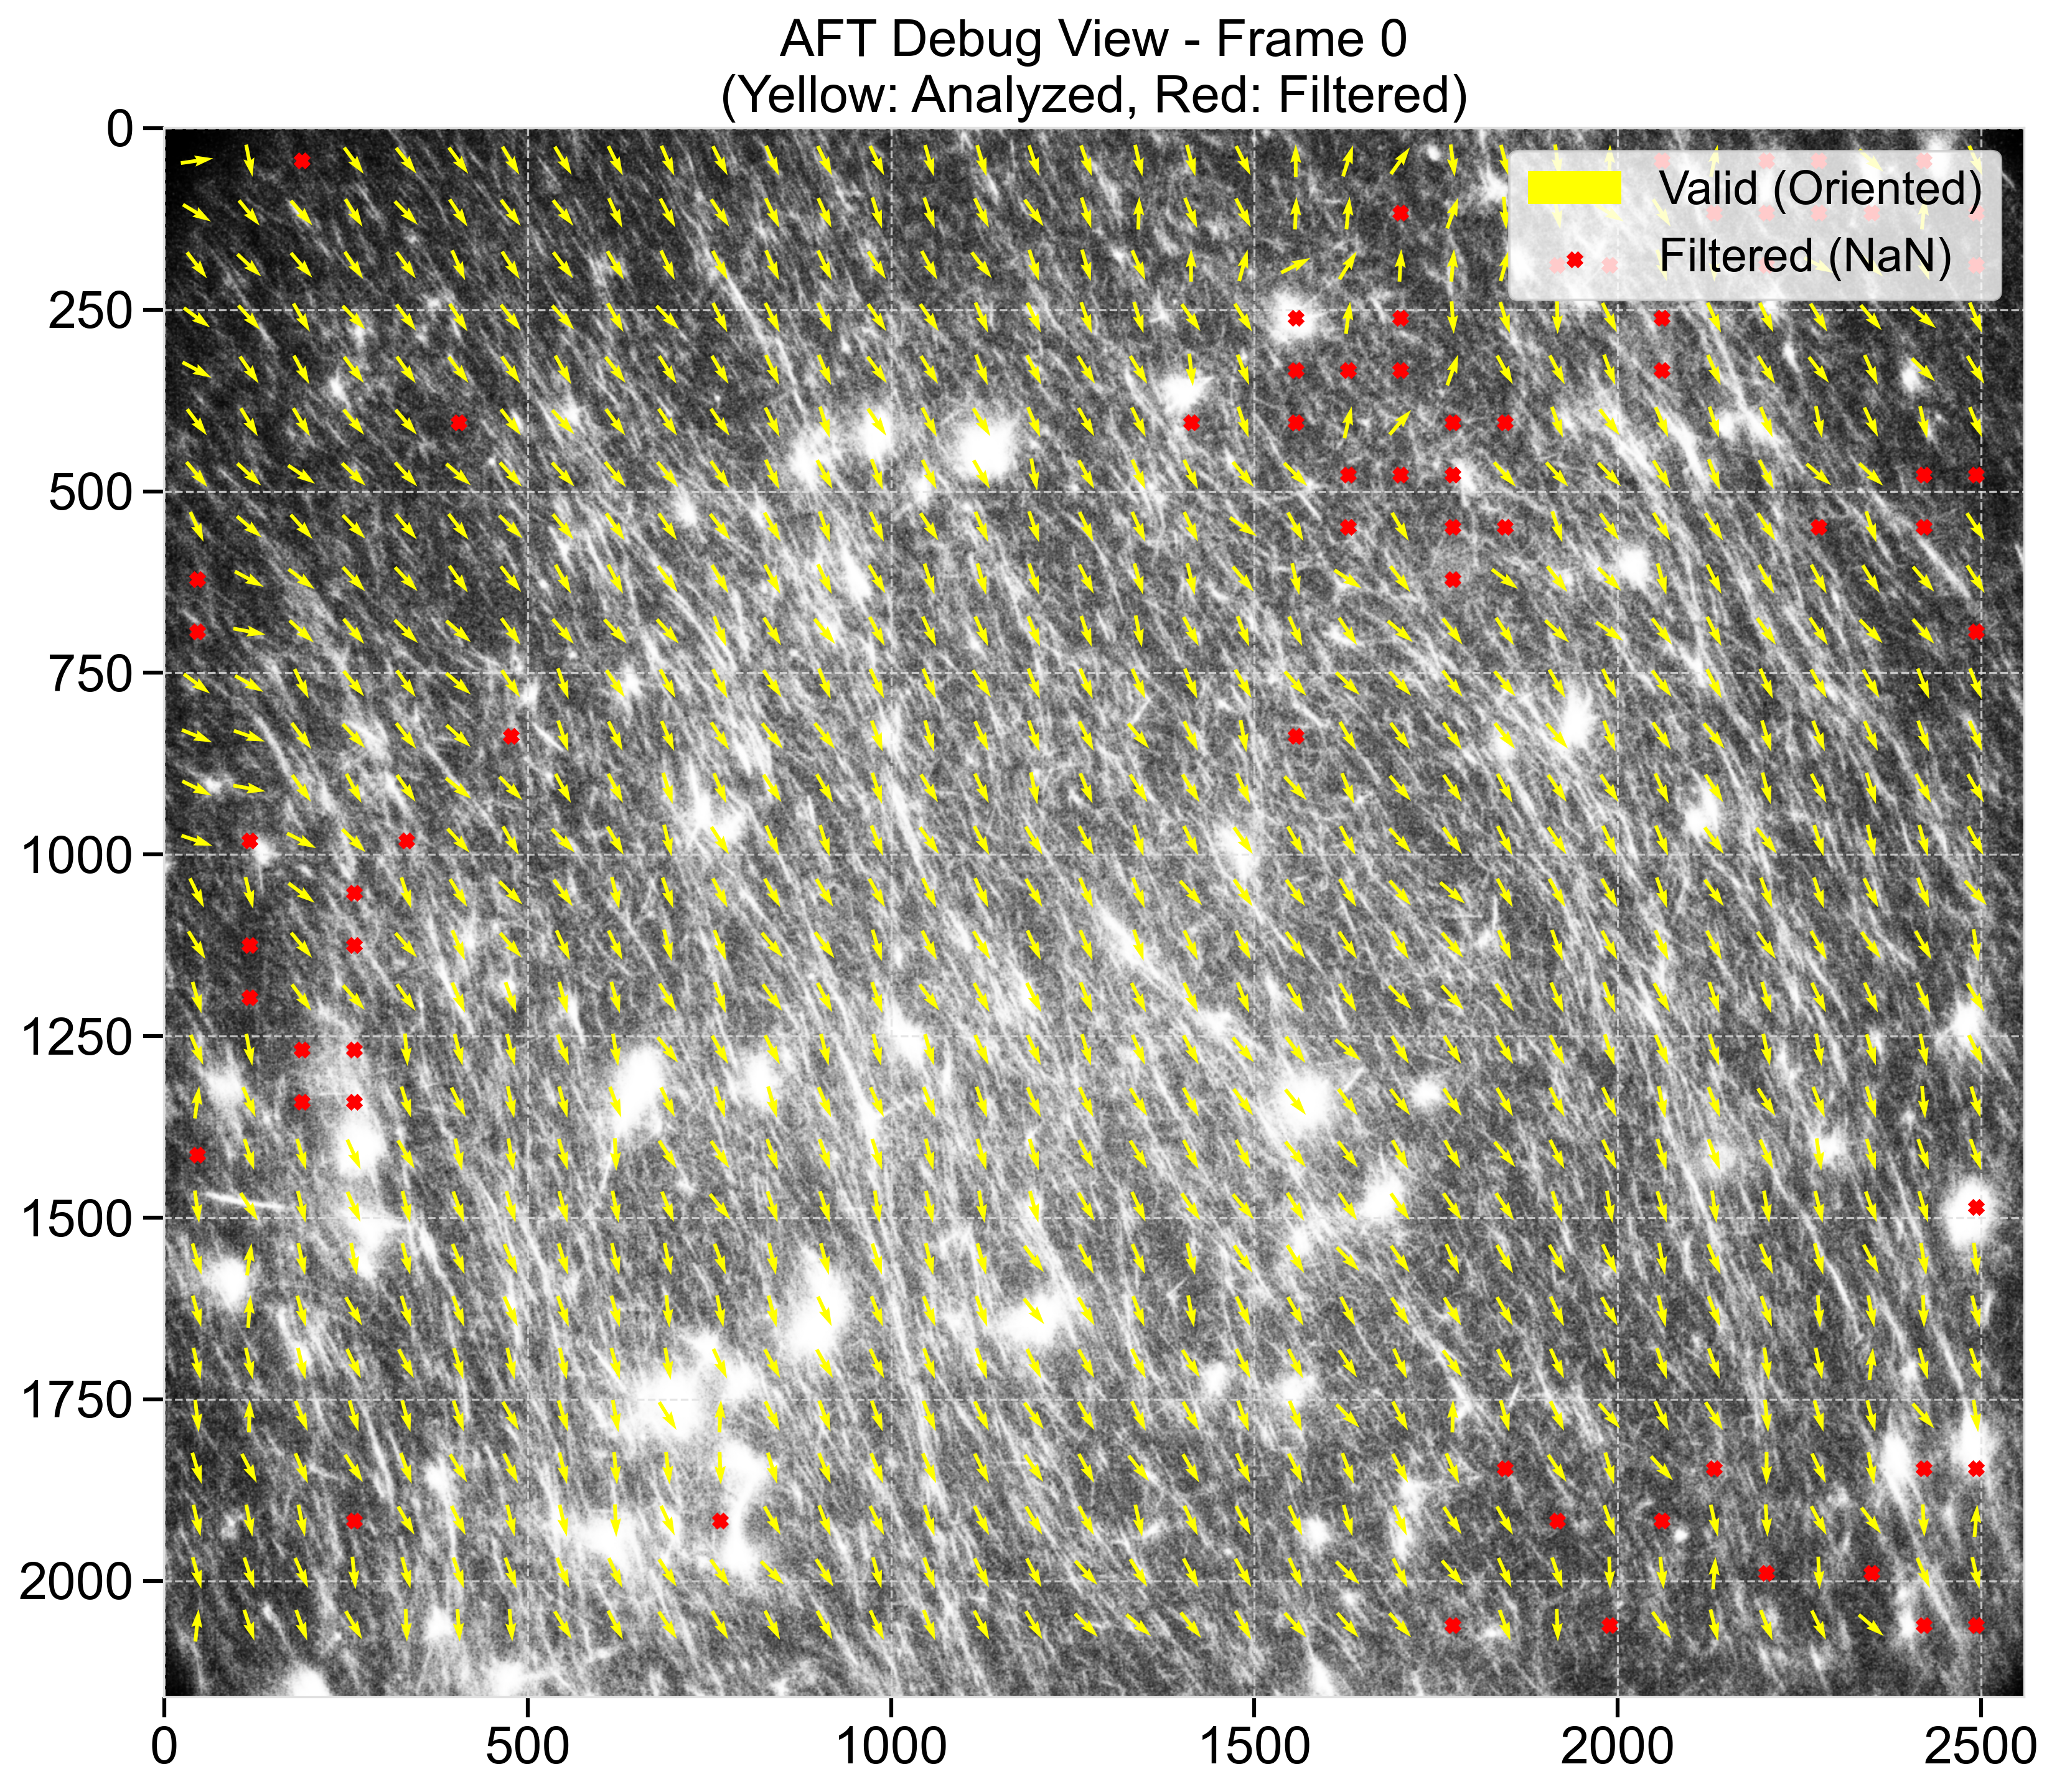

In [60]:
import numpy as np
import matplotlib.pyplot as plt

def plot_aft_debug(frame_idx, imstack, x, y, u_stack, v_stack, theta_stack, ecc_stack):
    """
    AFT解析の結果をデバッグ表示する関数
    """
    # 特定フレームのデータを取得
    img = imstack[frame_idx]
    # theta_stack と ecc_stack は (rows, cols) の2D配列なので平坦化して x, y に合わせる
    theta_f = theta_stack[frame_idx].flatten()
    #ecc_f = ecc_stack[frame_idx].flatten()
    u_f = u_stack[frame_idx]
    v_f = v_stack[frame_idx]
    
    # 有効なデータと NaN データのマスクを作成
    valid_mask = ~np.isnan(theta_f)
    nan_mask = np.isnan(theta_f)
    
    plt.figure(figsize=(12, 10))
    plt.imshow(img, cmap='gray')
    
    # 1. 有効なベクトルを黄色で表示 (Quiver)
    # AFT_toolsの仕様に合わせ pivot='mid' としています
    if np.any(valid_mask):
        plt.quiver(x[valid_mask], y[valid_mask], u_f[valid_mask], v_f[valid_mask], 
                   color='yellow', pivot='mid', scale_units='xy', scale=0.5, 
                   width=0.002, label='Valid (Oriented)')
    
    # 2. NaN（除外された場所）を赤い×印で表示
    if np.any(nan_mask):
        plt.scatter(x[nan_mask], y[nan_mask], color='red', s=20, marker='x', 
                    label='Filtered (NaN)')
    
    plt.title(f"AFT Debug View - Frame {frame_idx}\n(Yellow: Analyzed, Red: Filtered)")
    plt.legend(loc='upper right')
    plt.show()

# 実行例（notebook上で実行してください）
plot_aft_debug(0, green, x, y, u, v, im_theta, im_eccentricity)